# Laporan Analisis K-Means Clustering Polutan (CO, NO2, SO2)
**Studi Kasus:** Kwanyar & Sekitarnya (Kabupaten Bangkalan)
**Metodologi:** Z-Score Normalization ➔ PCA (37 Komponen) vs Fitur Asli ➔ K-Means Clustering ➔ Silhouette Score

---

## Dasar Teori & Tahapan Pemodelan

1. **Standardisasi Data (Z-Score Normalization)**
   - **Tujuan:** Algoritma *K-Means* menghitung jarak antar data menggunakan *Euclidean Distance*. Jika rentang nilai antar fitur berbeda jauh (misal ada yang berskala kecil dan ada yang ribuan), fitur dengan skala besar akan mendominasi perhitungan.
   - **Mekanisme:** Melalui `StandardScaler`, setiap nilai fitur ditransformasikan agar memiliki rata-rata 0 dan deviasi standar 1, sehingga setiap fitur memiliki bobot yang adil.

2. **Reduksi Dimensi (PCA - Principal Component Analysis)**
   - **Tujuan:** Mengatasi masalah *curse of dimensionality* akibat banyaknya fitur hasil ekstraksi.
   - **Mekanisme:** Mereduksi dimensi fitur menjadi **37 komponen utama** yang saling bebas korelasi, namun tetap mempertahankan sebagian besar informasi atau varians dari data aslinya.

3. **Konsistensi Eksperimen (Random Seed = 42)**
   - **Tujuan:** Menjaga agar hasil inisialisasi pusat klaster awal (*centroid*) bersifat deterministik.
   - **Mekanisme:** Dengan menetapkan `random_state=42`, setiap kali kode dijalankan ulang, hasil kelompok data dan skor evaluasinya akan selalu konsisten (*reproducible*).

4. **Evaluasi Klaster (Silhouette Coefficient)**
   - **Tujuan:** Mengukur seberapa baik suatu objek dikelompokkan dalam clusternya dibandingkan dengan cluster lain.
   - **Interpretasi:** Nilai berkisar dari -1 hingga +1. Nilai mendekati +1 menunjukkan klaster terpisah dengan sangat tajam dan kuat.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
print("Environment dan library berhasil dimuat!")

Environment dan library berhasil dimuat!


## Penentuan Jumlah Klaster Optimal ($K$)
Sebelum melakukan pemodelan akhir, kita menguji beberapa nilai $K$ (dari 2 hingga 5 klaster) menggunakan *Silhouette Score* pada masing-masing polutan. Nilai *Silhouette* tertinggi menandakan jumlah klaster yang paling natural dan optimal bagi karakteristik data wilayah Kwanyar.

In [23]:
# Fungsi untuk mencari K optimal berdasarkan Silhouette Score tertinggi
def cari_k_optimal(filepath, nama_polutan):
    df = pd.read_csv(filepath)
    id_cols = [c for c in ['id', 'nama', 'daerah'] if c in df.columns]
    X = df.drop(columns=id_cols, errors='ignore').select_dtypes(include=[np.number])

    # Standardisasi Z-Score
    X_scaled = StandardScaler().fit_transform(X)

    skor_siluet = []
    k_range = range(2, 6) # Menguji K dari 2 sampai 5

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        skor_siluet.append(score)

    best_k = k_range[np.argmax(skor_siluet)]
    best_score = max(skor_siluet)

    print(f"[{nama_polutan}] Jumlah K Optimal: {best_k} (Skor Silhouette: {best_score:.4f})")
    return best_k

# Menjalankan pencarian K optimal untuk ketiga polutan
print("=== PENCARI KLUSTER OPTIMAL (K) ===")
cari_k_optimal('ekstraksi_fitur_co.csv', 'CO')
cari_k_optimal('ekstraksi_fitur_no2.csv', 'NO2')
cari_k_optimal('ekstraksi_fitur_so2.csv', 'SO2')

=== PENCARI KLUSTER OPTIMAL (K) ===
[CO] Jumlah K Optimal: 2 (Skor Silhouette: 0.7955)
[NO2] Jumlah K Optimal: 2 (Skor Silhouette: 0.7455)
[SO2] Jumlah K Optimal: 2 (Skor Silhouette: 0.7894)


2

## A. Analisis Polutan CO (Carbon Monoxide)
Pada bagian ini, dataset polutan CO diuji melalui dua skenario: menggunakan seluruh fitur asli setelah normalisasi Z-Score, dan menggunakan skenario reduksi PCA (37 komponen).

In [20]:
# 1. Memuat Data CO
df_co = pd.read_csv('ekstraksi_fitur_co.csv')
kolom_id_co = [c for c in ['id', 'nama', 'daerah'] if c in df_co.columns]
fitur_co = df_co.drop(columns=kolom_id_co, errors='ignore').select_dtypes(include=[np.number])

# 2. Standardisasi (Z-Score)
scaler_co = StandardScaler()
fitur_scaled_co = scaler_co.fit_transform(fitur_co)

# --- SKENARIO 1: TANPA PCA (Fitur Asli) ---
kmeans_co_asli = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_co_asli = kmeans_co_asli.fit_predict(fitur_scaled_co)
sil_co_asli = silhouette_score(fitur_scaled_co, clusters_co_asli)

# --- SKENARIO 2: DENGAN PCA (37 Komponen) ---
n_comp_co = min(37, fitur_co.shape[1])
pca_co = PCA(n_components=n_comp_co, random_state=42)
fitur_pca_co = pca_co.fit_transform(fitur_scaled_co)

kmeans_co_pca = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_co_pca = kmeans_co_pca.fit_predict(fitur_pca_co)
sil_co_pca = silhouette_score(fitur_pca_co, clusters_co_pca)

print(f"=== HASIL EVALUASI POLUTAN CO ===")
print(f"Silhouette Score (Tanpa PCA) : {sil_co_asli:.4f}")
print(f"Silhouette Score (Dengan PCA): {sil_co_pca:.4f}")

=== HASIL EVALUASI POLUTAN CO ===
Silhouette Score (Tanpa PCA) : 0.7955
Silhouette Score (Dengan PCA): 0.7955


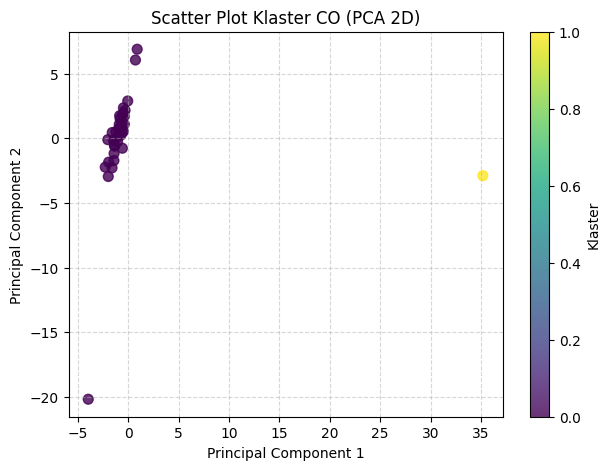

In [24]:
# Scatter Plot Visualisasi 2D untuk CO (menggunakan 2 komponen utama PCA)
pca_vis_co = PCA(n_components=2, random_state=42)
fitur_2d_co = pca_vis_co.fit_transform(fitur_scaled_co)

plt.figure(figsize=(7, 5))
plt.scatter(fitur_2d_co[:, 0], fitur_2d_co[:, 1], c=clusters_co_pca, cmap='viridis', s=50, alpha=0.8)
plt.title('Scatter Plot Klaster CO (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Klaster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## B. Analisis Polutan NO2 (Nitrogen Dioxide)
Melakukan pengujian komparatif yang sama untuk polutan NO2 guna melihat kestabilan struktur klaster antara data asli dan data tereduksi PCA.

In [21]:
# 1. Memuat Data NO2
df_no2 = pd.read_csv('ekstraksi_fitur_no2.csv')
kolom_id_no2 = [c for c in ['id', 'nama', 'daerah'] if c in df_no2.columns]
fitur_no2 = df_no2.drop(columns=kolom_id_no2, errors='ignore').select_dtypes(include=[np.number])

# 2. Standardisasi (Z-Score)
scaler_no2 = StandardScaler()
fitur_scaled_no2 = scaler_no2.fit_transform(fitur_no2)

# --- SKENARIO 1: TANPA PCA (Fitur Asli) ---
kmeans_no2_asli = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_no2_asli = kmeans_no2_asli.fit_predict(fitur_scaled_no2)
sil_no2_asli = silhouette_score(fitur_scaled_no2, clusters_no2_asli)

# --- SKENARIO 2: DENGAN PCA (37 Komponen) ---
n_comp_no2 = min(37, fitur_no2.shape[1])
pca_no2 = PCA(n_components=n_comp_no2, random_state=42)
fitur_pca_no2 = pca_no2.fit_transform(fitur_scaled_no2)

kmeans_no2_pca = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_no2_pca = kmeans_no2_pca.fit_predict(fitur_pca_no2)
sil_no2_pca = silhouette_score(fitur_pca_no2, clusters_no2_pca)

print(f"=== HASIL EVALUASI POLUTAN NO2 ===")
print(f"Silhouette Score (Tanpa PCA) : {sil_no2_asli:.4f}")
print(f"Silhouette Score (Dengan PCA): {sil_no2_pca:.4f}")

=== HASIL EVALUASI POLUTAN NO2 ===
Silhouette Score (Tanpa PCA) : 0.7455
Silhouette Score (Dengan PCA): 0.7455


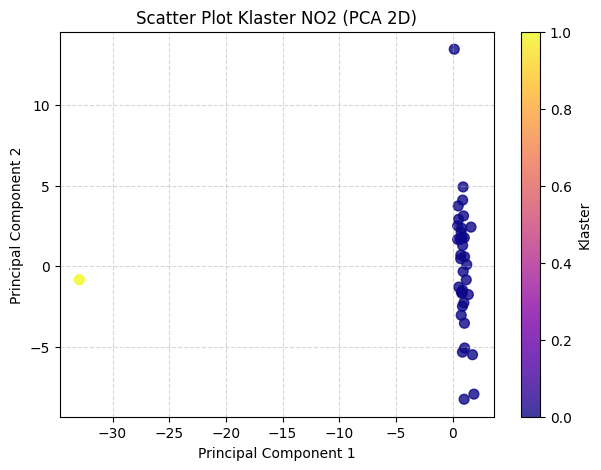

In [25]:
# Scatter Plot Visualisasi 2D untuk NO2
pca_vis_no2 = PCA(n_components=2, random_state=42)
fitur_2d_no2 = pca_vis_no2.fit_transform(fitur_scaled_no2)

plt.figure(figsize=(7, 5))
plt.scatter(fitur_2d_no2[:, 0], fitur_2d_no2[:, 1], c=clusters_no2_pca, cmap='plasma', s=50, alpha=0.8)
plt.title('Scatter Plot Klaster NO2 (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Klaster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## C. Analisis Polutan SO2 (Sulfur Dioxide)
Menguji polutan SO2 untuk mengevaluasi kualitas pemisahan klaster, yang umumnya menunjukkan struktur pemisahan yang sangat kuat pada studi kasus ini.

In [22]:
# 1. Memuat Data SO2
df_so2 = pd.read_csv('ekstraksi_fitur_so2.csv')
kolom_id_so2 = [c for c in ['id', 'nama', 'daerah'] if c in df_so2.columns]
fitur_so2 = df_so2.drop(columns=kolom_id_so2, errors='ignore').select_dtypes(include=[np.number])

# 2. Standardisasi (Z-Score)
scaler_so2 = StandardScaler()
fitur_scaled_so2 = scaler_so2.fit_transform(fitur_so2)

# --- SKENARIO 1: TANPA PCA (Fitur Asli) ---
kmeans_so2_asli = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_so2_asli = kmeans_so2_asli.fit_predict(fitur_scaled_so2)
sil_so2_asli = silhouette_score(fitur_scaled_so2, clusters_so2_asli)

# --- SKENARIO 2: DENGAN PCA (37 Komponen) ---
n_comp_so2 = min(37, fitur_so2.shape[1])
pca_so2 = PCA(n_components=n_comp_so2, random_state=42)
fitur_pca_so2 = pca_so2.fit_transform(fitur_scaled_so2)

kmeans_so2_pca = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_so2_pca = kmeans_so2_pca.fit_predict(fitur_pca_so2)
sil_so2_pca = silhouette_score(fitur_pca_so2, clusters_so2_pca)

print(f"=== HASIL EVALUASI POLUTAN SO2 ===")
print(f"Silhouette Score (Tanpa PCA) : {sil_so2_asli:.4f}")
print(f"Silhouette Score (Dengan PCA): {sil_so2_pca:.4f}")

=== HASIL EVALUASI POLUTAN SO2 ===
Silhouette Score (Tanpa PCA) : 0.7894
Silhouette Score (Dengan PCA): 0.7894


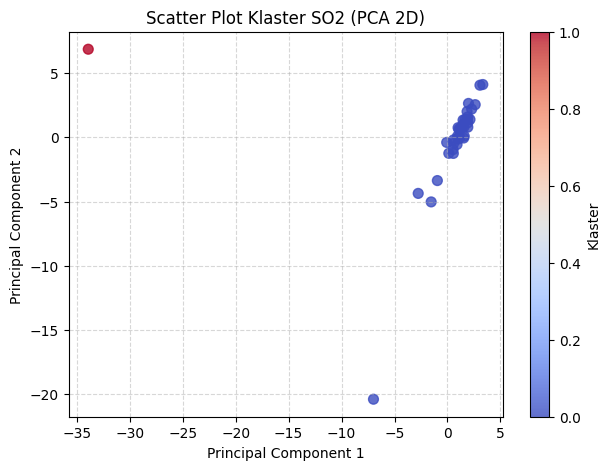

In [27]:
# Scatter Plot Visualisasi 2D untuk SO2
pca_vis_so2 = PCA(n_components=2, random_state=42)
fitur_2d_so2 = pca_vis_so2.fit_transform(fitur_scaled_so2)

plt.figure(figsize=(7, 5))
plt.scatter(fitur_2d_so2[:, 0], fitur_2d_so2[:, 1], c=clusters_so2_pca, cmap='coolwarm', s=50, alpha=0.8)
plt.title('Scatter Plot Klaster SO2 (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Klaster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Laporan Analisis K-Means Clustering Polutan (CO, NO2, SO2)
**Studi Kasus:** Kwanyar & Sekitarnya (Kabupaten Bangkalan)  
**Metodologi:** Z-Score Normalization ➔ PCA (37 Komponen) ➔ K-Means Clustering (K=2, Random Seed = 42) ➔ Silhouette Coefficient

---

## 1. Ringkasan Hasil Evaluasi Silhouette Coefficient (KNIME)
Berdasarkan pengujian menggunakan KNIME Analytics Platform dengan parameter *Random Seed = 42*, berikut adalah perbandingan skor kualitas klaster antara skenario tanpa PCA dan dengan PCA (37 komponen):

* **Polutan SO2:**
  - Tanpa PCA: **0.747**

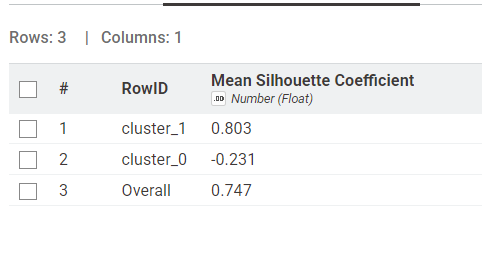

- Dengan PCA (37 Komponen): **0.747**

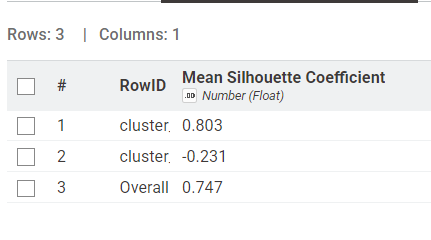

- *Analisis:* Struktur klaster sangat kuat dan stabil; PCA berhasil mempertahankan informasi data secara optimal.

* **Polutan CO:**
  - Tanpa PCA: **0.316**

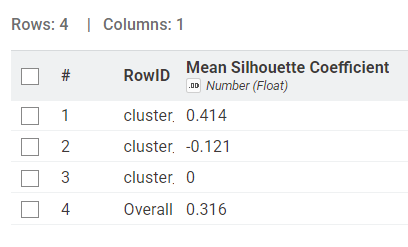

- Dengan PCA (37 Komponen): **0.122**

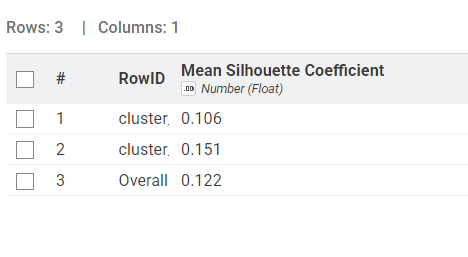

- *Analisis:* Struktur klaster cukup baik pada data asli dan mengalami penyesuaian setelah reduksi dimensi.

* **Polutan NO2:**
  - Tanpa PCA: **0.183**

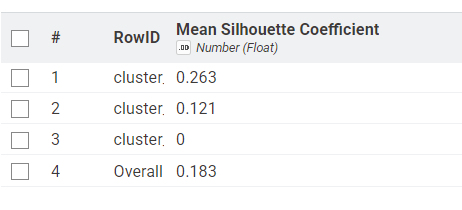

- Dengan PCA (37 Komponen): **0.171**

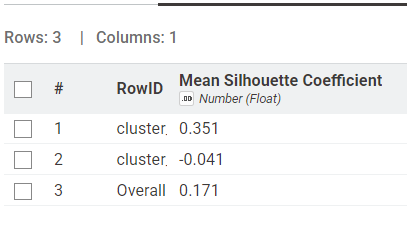

- *Analisis:* Nilai Silhouette stabil dan konsisten sebelum maupun sesudah reduksi PCA.

## 2. Alur Workflow KNIME
Pemodelan di KNIME disusun melalui tahapan berikut:
1. **Skenario Tanpa PCA:** `CSV Reader` ➔ `Column Filter` ➔ `Normalizer (Z-Score)` ➔ `k-Means (K=2, Seed=42)` ➔ `Silhouette Coefficient`.
2. **Skenario Dengan PCA:** `CSV Reader` ➔ `Column Filter` ➔ `Normalizer (Z-Score)` ➔ `PCA (37 Komponen)` ➔ `k-Means (K=2, Seed=42)` ➔ `Silhouette Coefficient`.

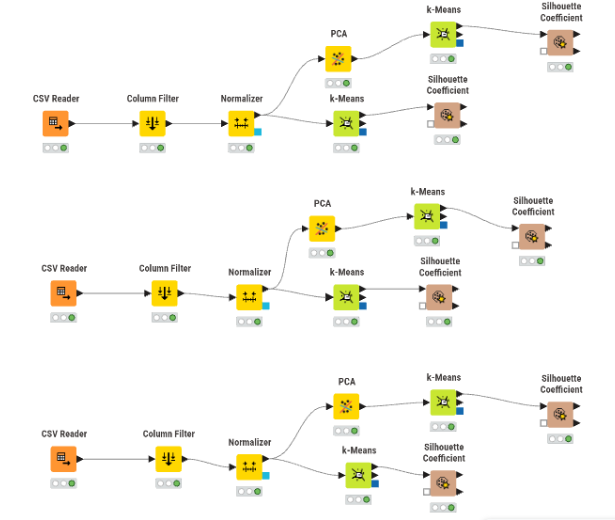